*Implement the task performed in the lab manual mentioned in the lab number 3 but the dataset should be of your own choice and not the one mentioned in the lab manual.*

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('Building_Permits.csv')
df.sample(5)

C:\Users\User\AppData\Local\Temp\ipykernel_10356\3297392428.py:1: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('Building_Permits.csv')


,Permit Number,Permit Type,Permit Type Definition,Permit Creation Date,Block,Lot,Street Number,Street Number Suffix,Street Name,Street Suffix,...,Existing Construction Type,Existing Construction Type Description,Proposed Construction Type,Proposed Construction Type Description,Site Permit,Supervisor District,Neighborhoods - Analysis Boundaries,Zipcode,Location,Record ID
128469,201606240879,3,additions alterations or repairs,06/24/2016,3629,033,1027,NaN,Church,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,8.0,Noe Valley,94114.0,"(37.75441602497602, -122.42732571710812)",1427994163140
7842,201303263021,8,otc alterations permit,03/26/2013,0715,051,151,NaN,Alice B Toklas,Pl,...,1.0,constr type 1,1.0,constr type 1,NaN,6.0,Tenderloin,94109.0,"(37.785087993054866, -122.42067400449834)",1299813396507
132690,M711407,8,otc alterations permit,08/05/2016,0564C,005,2288,NaN,Broadway,NaN,...,NaN,NaN,NaN,NaN,NaN,2.0,Pacific Heights,94123.0,"(37.79461003946054, -122.43467610894045)",1432760478165
88038,201506058206,8,otc alterations permit,06/05/2015,6655,064,307,NaN,30th,St,...,5.0,wood frame (5),5.0,wood frame (5),NaN,8.0,Glen Park,94131.0,"(37.74179359127987, -122.4272090679868)",1384119210123
50734,201406107953,8,otc alterations permit,06/10/2014,2609,020,188,NaN,Alpine,Tr,...,5.0,wood frame (5),5.0,wood frame (5),NaN,8.0,Castro/Upper Market,94117.0,"(37.76746660292596, -122.43757015163936)",1344715499095


In [3]:
# Calculate missing percentage

missing_percentage = (df.isnull().sum() / len(df)) * 100

In [4]:
# Create a dataframe for missing data information
missing_data = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': missing_percentage
})


print("\nMissing Data Information:")
print(missing_data)


Missing Data Information:
                                        Missing Values  Missing Percentage
Permit Number                                        0            0.000000
Permit Type                                          0            0.000000
Permit Type Definition                               0            0.000000
Permit Creation Date                                 0            0.000000
Block                                                0            0.000000
Lot                                                  0            0.000000
Street Number                                        0            0.000000
Street Number Suffix                            196684           98.885872
Street Name                                          0            0.000000
Street Suffix                                     2768            1.391654
Unit                                            169421           85.178984
Unit Suffix                                     196939           99.01407

In [5]:
missing_20 = missing_data[
    (missing_data['Missing Percentage'] >= 15) &
    (missing_data['Missing Percentage'] <= 25)
]


print("\nFeatures Having Approximately 20% Missing Data:")
print(missing_20)


Features Having Approximately 20% Missing Data:
                                        Missing Values  Missing Percentage
Number of Existing Stories                       42784           21.510307
Number of Proposed Stories                       42868           21.552539
Estimated Cost                                   38066           19.138260
Existing Use                                     41114           20.670689
Proposed Use                                     42439           21.336853
Plansets                                         37309           18.757667
Existing Construction Type                       43366           21.802916
Existing Construction Type Description           43366           21.802916
Proposed Construction Type                       43162           21.700352
Proposed Construction Type Description           43162           21.700352


In [8]:
# remove rows having missing values in Existing Use column

new_df_Existing_Use = df.dropna(subset=['Existing Use'])

# check missing values after removing rows

new_df_Existing_Use['Existing Use'].isnull().sum()

np.int64(0)

In [9]:
# shape before removing rows

df.shape

# shape after removing rows

new_df_Existing_Use.shape

(157786, 43)

<Axes: >

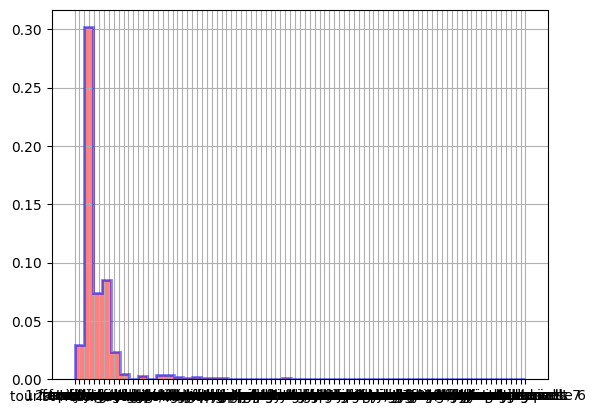

In [10]:
new_df = df.dropna(subset=['Existing Use'])

df['Existing Use'].hist(bins=50, density=True, color = 'blue', label="before", alpha=0.5, histtype='step', linewidth = 2)

new_df['Existing Use'].hist(bins=50, density=True, color = 'red', label="After", alpha=0.5, )
